#***Importing Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

#***Loading Dataset***

In [ ]:
df =pd.read_csv('/content/movie_metadata.csv')

#***Feature Engineering⚙️***

In [ ]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,Classify,Classify_Encoded
0,1,922,723.0,178.000000,0.0,855.0,1405,1000.0,7.605058e+08,106,...,62,7,2.370000e+08,2009.0,936.0,7.9,1.78,33000,Hit,2
1,1,794,302.0,169.000000,563.0,1000.0,2216,40000.0,3.094042e+08,100,...,62,7,3.000000e+08,2007.0,5000.0,7.1,2.35,0,Hit,2
2,1,2021,602.0,148.000000,0.0,161.0,2487,11000.0,2.000742e+08,127,...,61,7,2.450000e+08,2015.0,393.0,6.8,2.35,85000,Hit,2
3,1,373,813.0,164.000000,22000.0,23000.0,532,27000.0,4.481306e+08,287,...,62,7,2.500000e+08,2012.0,23000.0,8.5,2.35,164000,Hit,2
4,2,600,NaN,107.201074,131.0,NaN,2431,131.0,4.846841e+07,753,...,65,18,3.975262e+07,NaN,12.0,7.1,NaN,0,Hit,2


In [ ]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'Classify',
       'Classify_Encoded'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
genres,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5043 non-null   int64  
 1   director_name              5043 non-null   int64  
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5043 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5043 non-null   int64  
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      5043 non-null   float64
 9   genres                     5043 non-null   int64  
 10  actor_1_name               5043 non-null   int64  
 11  movie_title                5043 non-null   int64  
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [ ]:
df['duration']=df['duration'].fillna(df['duration'].mean())
df['gross'] = df['gross'].fillna(df['gross'].mean())
df['budget'] = df['budget'].fillna(df['budget'].mean())

In [ ]:
def categorize_score(score):
    if score <= 3: return 'Flop'
    elif score <= 6: return 'Average'
    else: return 'Hit'

df['Classify'] = df['imdb_score'].apply(categorize_score)

#***Label Encoding***

In [ ]:
feature_columns = ['director_name', 'duration', 'actor_1_name','budget', 'gross', 'language', 'country']
encoders = {}
default_values = {}

# Handling Ctagorical Variable
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Classify':
        default_values[col] = df[col].mode()[0]

        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

In [ ]:
default_values['budget'] = df['budget'].median()
default_values['gross'] = df['gross'].median()
default_values['actor_1_name'] = df['actor_1_name'].mode()[0]

In [ ]:
le = LabelEncoder()
df['Classify_Encoded'] = le.fit_transform(df['Classify'])

#***Training and Splitting***

In [ ]:
X=df[feature_columns]
y = df['Classify_Encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
models = {"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.2f}")
    print(f"--- {name} Results ---")
    print(classification_report(y_test, y_pred, zero_division=1))

Accuracy: 0.73
--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.60      0.38      0.46       308
           1       1.00      0.00      0.00         9
           2       0.76      0.90      0.82       692

    accuracy                           0.73      1009
   macro avg       0.79      0.42      0.43      1009
weighted avg       0.71      0.73      0.71      1009

Accuracy: 0.66
--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.06      0.01      0.01       308
           1       1.00      0.00      0.00         9
           2       0.68      0.96      0.80       692

    accuracy                           0.66      1009
   macro avg       0.58      0.32      0.27      1009
weighted avg       0.49      0.66      0.55      1009



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.3f}   → overall correctness")
print(f"Precision: {precision:.3f}   → how many predicted positives are correct")
print(f"Recall:    {recall:.3f}   → how many actual positives were found")
print(f"F1-score:  {f1:.3f}   → balance between precision and recall")
print("\nConfusion Matrix:")
print(cm)

Accuracy:  0.661   → overall correctness
Precision: 0.486   → how many predicted positives are correct
Recall:    0.661   → how many actual positives were found
F1-score:  0.550   → balance between precision and recall

Confusion Matrix:
[[  2   0 306]
 [  2   0   7]
 [ 27   0 665]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#***Visualization***

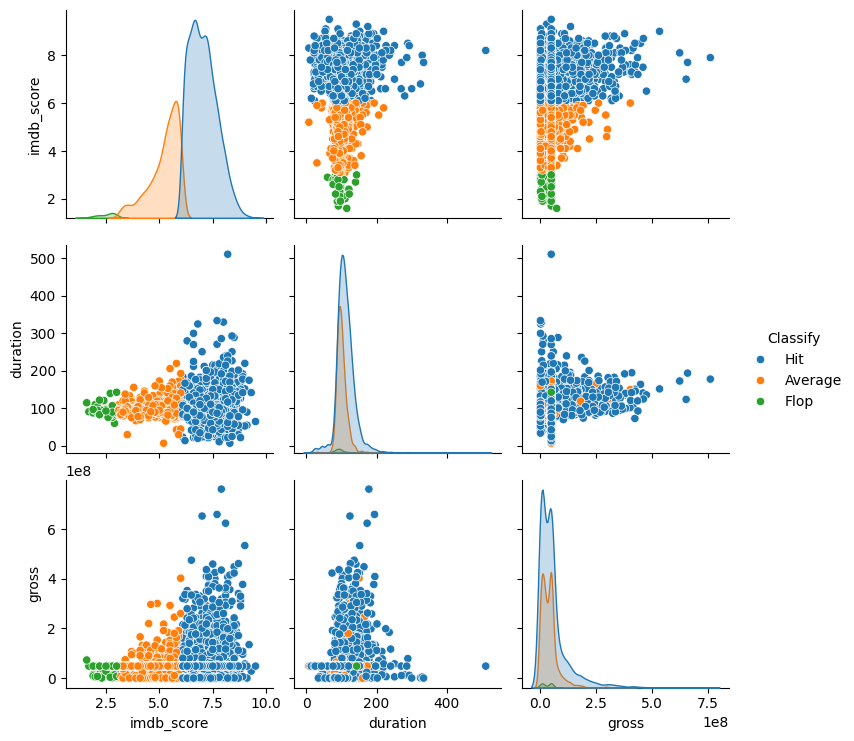

In [ ]:
sns.pairplot(df[['imdb_score', 'duration', 'gross', 'Classify']], hue='Classify')
plt.show()

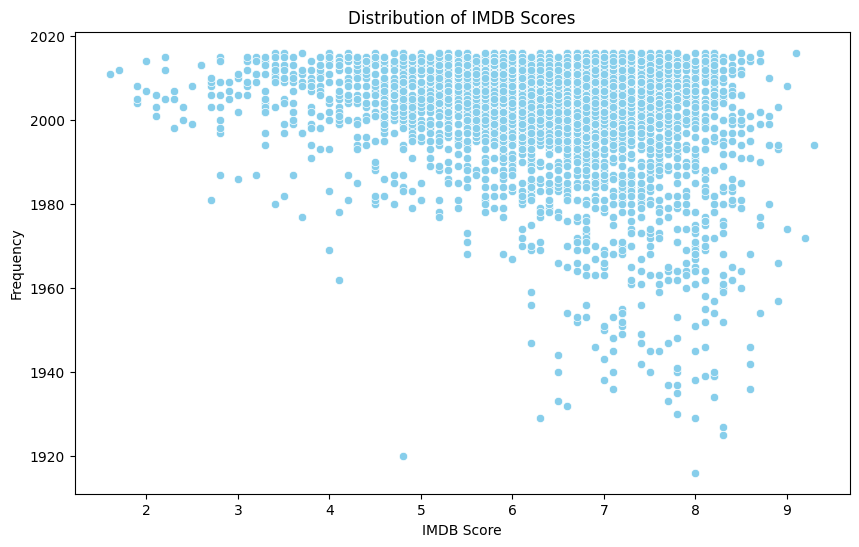

In [ ]:
# @title
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['imdb_score'],y=df['title_year'], color='skyblue')
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.ylabel('Frequency')
plt.savefig('imdb_score_distribution.png')

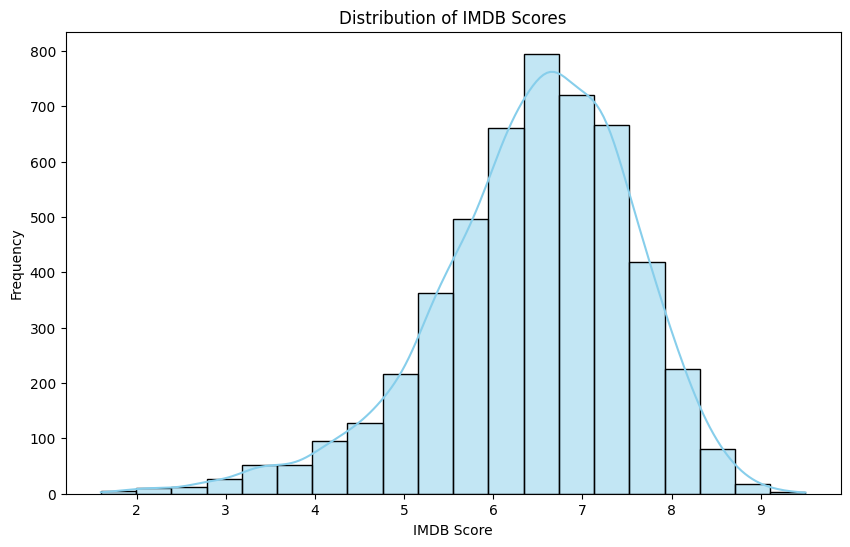

In [ ]:
# @title
plt.figure(figsize=(10, 6))
sns.histplot(df['imdb_score'],bins=20 ,kde=True, color='skyblue')
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.ylabel('Frequency')
plt.savefig('imdb_score_distribution.png')

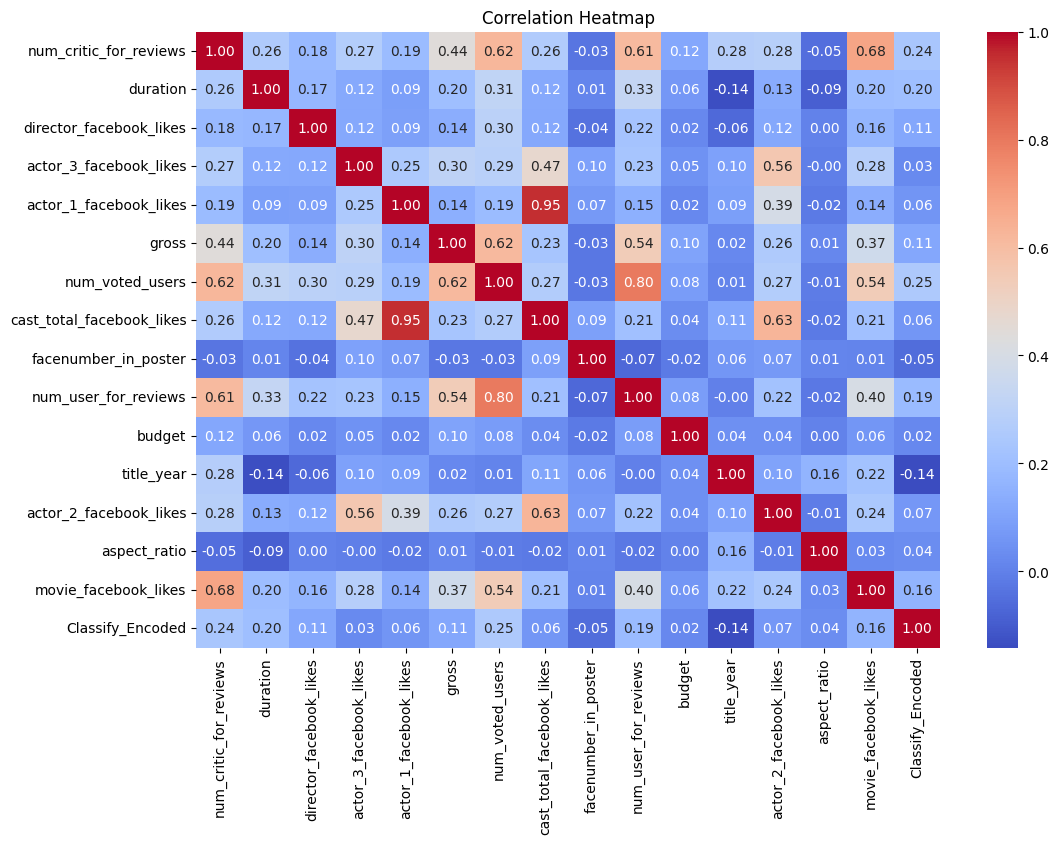

In [ ]:
# @title
drop_cols = ['movie_title', 'movie_imdb_link', 'plot_keywords', 'genres',
             'imdb_score','actor_2_name','actor_1_name','actor_3_name',
             'content_rating','color','language','country','genres','Classify',
             'director_name']

df1=df.drop(columns= drop_cols)

correlation_matrix = df1.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

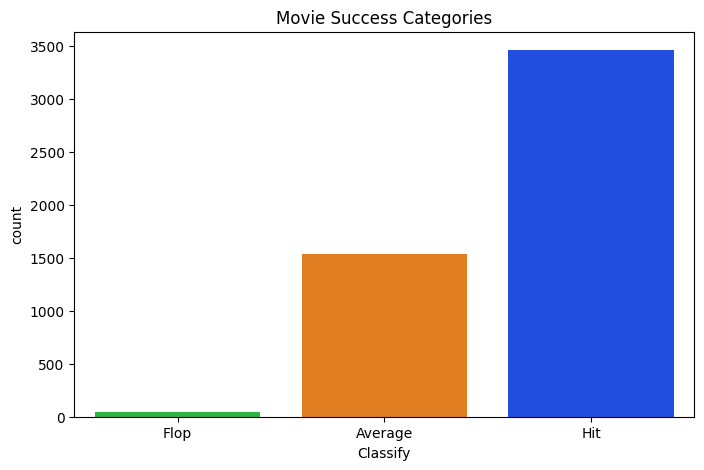

In [ ]:
# @title
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Classify', order=['Flop', 'Average', 'Hit'], palette='bright',hue='Classify')
plt.title('Movie Success Categories')
legend=False
plt.savefig('category_counts.png')
plt.show()

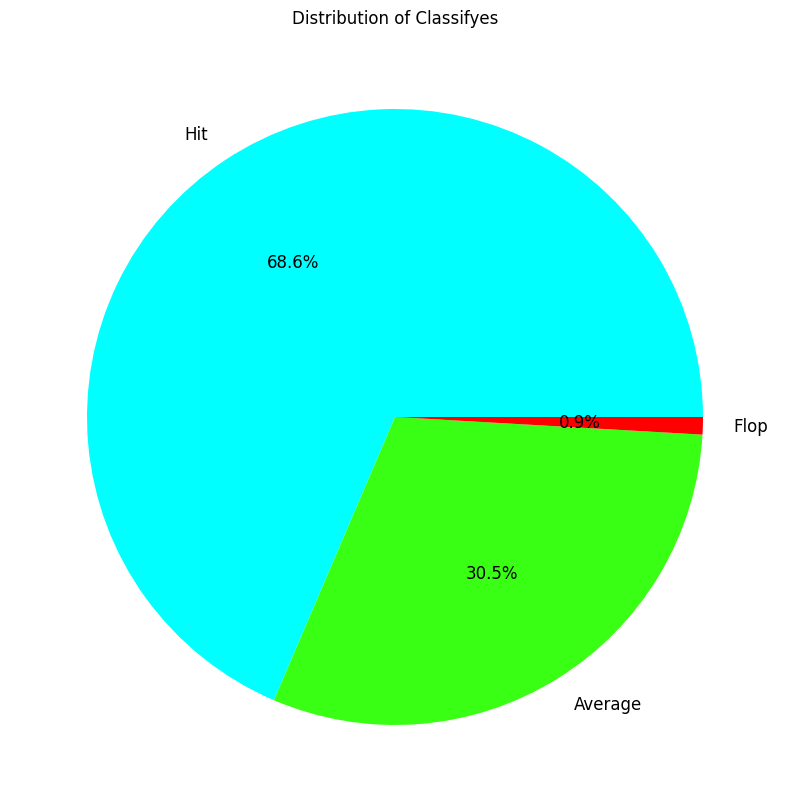

In [ ]:
# @title
movie_class_counts = df['Classify'].value_counts()
ax = (movie_class_counts * 100.0 / movie_class_counts.sum()) \
.plot.pie(
    autopct='%.1f%%',
    labels=movie_class_counts.index,
    figsize=(10, 10),
    fontsize=12,
    colors=['#00ffff', '#39ff14', '#ff0000']
)
plt.title('Distribution of Classifyes')
plt.ylabel('')
plt.show()

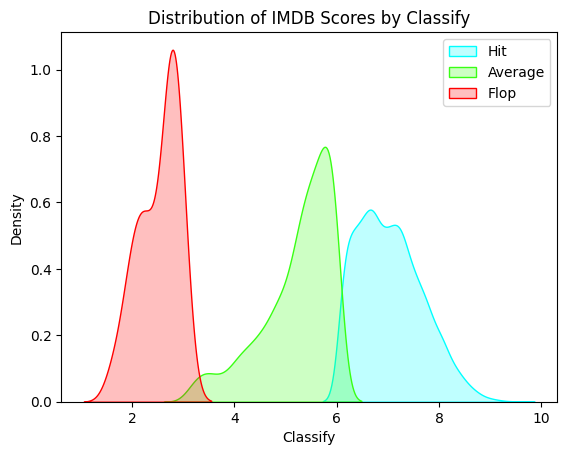

In [ ]:
# @title
ax = sns.kdeplot(
    df['imdb_score'][(df['Classify'] == 'Hit')],
    color="#00ffff",
    fill=True)

ax = sns.kdeplot(
    df['imdb_score'][(df['Classify'] == 'Average')],
    color="#39ff14",
    fill=True)

ax = sns.kdeplot(
    df['imdb_score'][(df['Classify'] == 'Flop')],
    color="#ff0000",
    fill=True)

ax.legend(["Hit", "Average", "Flop"], loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Classify')
ax.set_title('Distribution of IMDB Scores by Classify')
plt.show()

confusion_matrix_Random_Forest.png


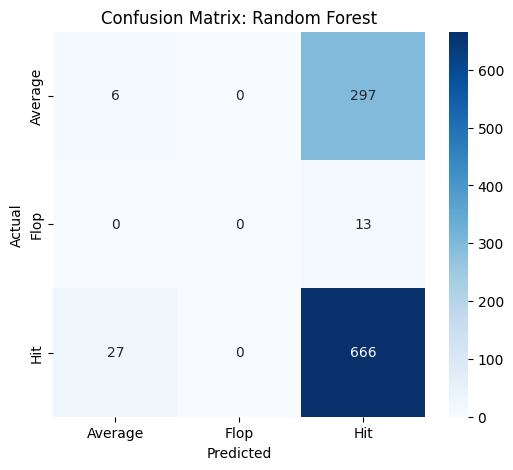

In [ ]:
# @title
plt.figure(figsize=(6, 5))
model_name = "Random Forest"
file_name_model = model_name.replace(" ", "_")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix: {model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(f'confusion_matrix_{file_name_model}.png')

print(f'confusion_matrix_{file_name_model}.png')

#***User Input Prediction***

In [ ]:
def predict_movie_success():
    print("\n" + "="*40)
    print(" MOVIE SUCCESS PREDICTOR")
    print("="*40)

    print("Please enter the movie details:")
    u_director = input("Director Name (e.g., Christopher Nolan): ").strip()
    u_duration = float(input("Duration (minutes): "))
    u_language = input("Language (e.g., English): ").strip()
    u_country  = input("Country (e.g., USA): ").strip()

  # ---- Director ----
    if u_director in encoders['director_name'].classes_:
        enc_director = encoders['director_name'].transform([u_director])[0]
    else:
        print(f"Note: '{u_director}' not found in training data. Using default/average director impact.")
        enc_director = encoders['director_name'].transform([default_values['director_name']])[0]


  # ---- Language ----
    if u_language in encoders['language'].classes_:
        enc_language = encoders['language'].transform([u_language])[0]
    else:
        print(f"Note: '{u_language}' not found. Using default language.")
        enc_language = encoders['language'].transform([default_values['language']])[0]


  # ---- Country ----
    if u_country in encoders['country'].classes_:
        enc_country = encoders['country'].transform([u_country])[0]
    else:
        print(f"Note: '{u_country}' not found. Using default country.")
        enc_country = encoders['country'].transform([default_values['country']])[0]

# Creating Dummy Values for Model
    dummy_actor = default_values['actor_1_name']
    dummy_budget = default_values['budget']
    dummy_gross = default_values['gross']


    input_data = np.array([[
        enc_director,
        u_duration,
        dummy_actor,
        dummy_budget,
        dummy_gross,
        enc_language,
        enc_country
    ]])


# Scalling Data
    input_data_scaled = scaler.transform(input_data)


# Prediction
    prediction_code = model.predict(input_data_scaled)[0]
    prediction_label =le.inverse_transform([prediction_code])[0]

    print("-" * 30)
    print(f"PREDICTION: This movie is likely to be a: {prediction_label.upper()}")
    print("-" * 30)



#***Predictor***

In [ ]:

while True:
    predict_movie_success()
    cont = input("Do you want to predict another movie? (yes/no): ")
    if cont.lower() != 'yes'and cont.lower() != 'y':
        break


 MOVIE SUCCESS PREDICTOR
Please enter the movie details:
Director Name (e.g., Christopher Nolan): Christopher Nolan
Duration (minutes): 156
Language (e.g., English): Korean
Country (e.g., USA): USA


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


------------------------------
PREDICTION: This movie is likely to be a: HIT
------------------------------
Do you want to predict another movie? (yes/no): N
